#Analisis inicial de los datos

Empiezo con la exploración para conocer cómo se distribuyen los datos

In [ ]:
#Empiezo importando mi base de datos

import pandas as pd
import numpy as np

train = pd.read_csv('datos_train.csv')
target = pd.read_csv('target_entrenamiento.csv')
test = pd.read_csv('datos_test.csv')

In [ ]:
#Observo las dimensiones del dataset

print('train:',train.shape)
print('target:',target.shape)
print('test:',test.shape)

train: (59400, 40)
target: (59400, 2)
test: (14850, 40)


In [ ]:
#Analizo que los primeros valores de train y test coincidan
print('TRAIN:')
print(train.head(2))
print('TARGET:')
print(target.head(2))
print('TEST:')
print(test.head(2))

TRAIN:
      id  amount_tsh date_recorded   funder  gps_height installer  longitude  \
0  69572      6000.0    2011-03-14    Roman        1390     Roman  34.938093   
1   8776         0.0    2013-03-06  Grumeti        1399   GRUMETI  34.698766   

   latitude  wpt_name  num_private  ... payment_type water_quality  \
0 -9.856322      none            0  ...     annually          soft   
1 -2.147466  Zahanati            0  ...    never pay          soft   

  quality_group      quantity  quantity_group                source  \
0          good        enough          enough                spring   
1          good  insufficient    insufficient  rainwater harvesting   

            source_type  source_class     waterpoint_type  \
0                spring   groundwater  communal standpipe   
1  rainwater harvesting       surface  communal standpipe   

  waterpoint_type_group  
0    communal standpipe  
1    communal standpipe  

[2 rows x 40 columns]
TARGET:
      id status_group
0  69572   f

In [ ]:
#Observo que de que tipo es el dato de cada columna
print(train.dtypes)

id                         int64
amount_tsh               float64
date_recorded             object
funder                    object
gps_height                 int64
installer                 object
longitude                float64
latitude                 float64
wpt_name                  object
num_private                int64
basin                     object
subvillage                object
region                    object
region_code                int64
district_code              int64
lga                       object
ward                      object
population                 int64
public_meeting            object
recorded_by               object
scheme_management         object
scheme_name               object
permit                    object
construction_year          int64
extraction_type           object
extraction_type_group     object
extraction_type_class     object
management                object
management_group          object
payment                   object
payment_ty

Con esta información podemos deducir:

- Variables numéricas: id, gps_height, num_private, region_code, district_code, population, construction_year

- Variables categóricas: todas las demás que cuentan con el dtype object

- date_recorded aparece como una variable categórica y es una fecha, por lo que lo tendré que cambiar

In [ ]:
# Investigo cuantas clases de bombas hay en el dataset target

print('Numero de bombas diferentes:', target['status_group'].value_counts())
print('Porcentaje de que cada clase:', target['status_group'].value_counts(normalize= True)*100)

Numero de bombas diferentes: status_group
functional                 32259
non functional             22824
functional needs repair     4317
Name: count, dtype: int64
Porcentaje de que cada clase: status_group
functional                 54.308081
non functional             38.424242
functional needs repair     7.267677
Name: proportion, dtype: float64


Con estos resultados puedo afirmar que se trata de un dataset desbalanceado, porque una de sus clases tiene una proporción minoritaria del 7% y otra una proporción mayoritaria del 54%.

In [ ]:
#Calculo cuales son las columnas que tienen nulos

print('Columnas con nulos en train:')
nulos = train.isnull().sum()
print(nulos[nulos > 0])
print('Porcentaje de nulos en comparación con el total;')
print((nulos[nulos > 0]/len(train)) *100)

Columnas con nulos en train:
funder                3637
installer             3655
wpt_name                 2
subvillage             371
public_meeting        3334
scheme_management     3878
scheme_name          28810
permit                3056
dtype: int64
Porcentaje de nulos en comparación con el total;
funder                6.122896
installer             6.153199
wpt_name              0.003367
subvillage            0.624579
public_meeting        5.612795
scheme_management     6.528620
scheme_name          48.501684
permit                5.144781
dtype: float64


Observando los nulos se aprecia que la variable scheme_name tiene 28.810 nulos, prácticamente la mitad de sus registros en el dataset son nulos (48,46%). El resto de variables cuentan con menos nulos que pueden ser más manejables.

In [ ]:
# Identifico los valores extraños en la variables numericas

print(train.describe())

                 id     amount_tsh    gps_height     longitude      latitude  \
count  59400.000000   59400.000000  59400.000000  59400.000000  5.940000e+04   
mean   37115.131768     317.650385    668.297239     34.077427 -5.706033e+00   
std    21453.128371    2997.574558    693.116350      6.567432  2.946019e+00   
min        0.000000       0.000000    -90.000000      0.000000 -1.164944e+01   
25%    18519.750000       0.000000      0.000000     33.090347 -8.540621e+00   
50%    37061.500000       0.000000    369.000000     34.908743 -5.021597e+00   
75%    55656.500000      20.000000   1319.250000     37.178387 -3.326156e+00   
max    74247.000000  350000.000000   2770.000000     40.345193 -2.000000e-08   

        num_private   region_code  district_code    population  \
count  59400.000000  59400.000000   59400.000000  59400.000000   
mean       0.474141     15.297003       5.629747    179.909983   
std       12.236230     17.587406       9.633649    471.482176   
min        0.00

Con estos resultados puedo decir que hay valores mínimos que me parecen extraños como:
- longitude = 0: esto es imposible ya que ninguna bomba está en el meridiano 0
- construction_year = 0: no tiene sentido, no existe el año 0
- population = 0: tampoco tiene sentido, son datos faltantes disfrazados de ceros
- amount_tsh = 0: el 75% de los registros de esta variable es 0, por lo que no tiene casi información útil



In [ ]:
# Calculo cuantos valores diferentes tienen las variables categóricas

variables_cat = train.select_dtypes(include= 'object').columns

for col in variables_cat:
  print(f'{col}: {train[col].nunique()} valores diferentes')

date_recorded: 356 valores diferentes
funder: 1896 valores diferentes
installer: 2145 valores diferentes
wpt_name: 37399 valores diferentes
basin: 9 valores diferentes
subvillage: 19287 valores diferentes
region: 21 valores diferentes
lga: 125 valores diferentes
ward: 2092 valores diferentes
public_meeting: 2 valores diferentes
recorded_by: 1 valores diferentes
scheme_management: 11 valores diferentes
scheme_name: 2695 valores diferentes
permit: 2 valores diferentes
extraction_type: 18 valores diferentes
extraction_type_group: 13 valores diferentes
extraction_type_class: 7 valores diferentes
management: 12 valores diferentes
management_group: 5 valores diferentes
payment: 7 valores diferentes
payment_type: 7 valores diferentes
water_quality: 8 valores diferentes
quality_group: 6 valores diferentes
quantity: 5 valores diferentes
quantity_group: 5 valores diferentes
source: 10 valores diferentes
source_type: 7 valores diferentes
source_class: 3 valores diferentes
waterpoint_type: 7 valor

Viendo los resultados puedo deducir que hay variables con una elevada cardinalidad y variables con pocos valores únicos:

- Variables con una alta cardinalidad: wpt_name, subvillage, ward, scheme_name, funder, installer.
- Variables con pocos valores únicos: basin, region, quantity, source_class, extraction_type_class, waterpoint_type_group.

Hay variables con información curiosa como recorded_by, que cuenta con un único valor (no aporta nada al modelo).

# Preprocesamiento:

In [ ]:
# Hago una copia por si acaso me equivoco y la lio en el orginal

train_ = train.copy()
test_ = test.copy()

Elimino las siguientes columnas porque aportan información redundante:

- recorded_by: solo tiene un valor por lo que no aporta nada al modelo
- wpt_name: tiene demasiados valores únicos, por lo que actúa casi como un ID sin aportar valor al modelo
- scheme_name: prácticamente la mitad de sus registros son nulos
- subvillage: tiene muchos valores únicos, por lo que es muy limitado el valor que puede aportar al modelo
- extraction_type y extraction_type_group: aportan la misma información que extraction_type_class
- payment_type: es igual a payment
- quantity_group: es la misma información que quantity
- source: es redundante con source_type
- source_class: también es redundante con source_type
- waterpoint_type_group: es igual que waterpoint_type
- management_group: muy similar a management
- quality_group: es redundante con water_quality


In [ ]:
# Elimino de train y de test las columnas innecesarias para el modelo

variables_eliminar = ['recorded_by','wpt_name', 'scheme_name', 'subvillage', 'extraction_type', 'extraction_type_group',
                      'payment_type', 'quantity_group', 'source', 'source_class', 'waterpoint_type_group', 'management_group',
                      'quality_group']
train_.drop(variables_eliminar, axis=1 , inplace= True)
test_.drop(variables_eliminar, axis=1 , inplace= True)

In [ ]:
#Compruebo que se hayan borrado bien

print(f'Columnas antes del borrado: {train.shape[1]}')
print(f'Columnas despues del borrado: {train_.shape[1]}')

Columnas antes del borrado: 40
Columnas despues del borrado: 27


In [ ]:
# Voy a cambiar los ceros incoherentes por nulos y asi de luego los podre imputar

columnas_con_ceros_raros = ['longitude', 'construction_year', 'population']

for col in columnas_con_ceros_raros:
  ceros = (train_[col] == 0).sum()
  print(f'{col}:{ceros} ceros cambiados')
  train_[col] = train_[col].replace(0, np.nan)
  test_[col] = train_[col].replace(0, np.nan)

longitude:1812 ceros cambiados
construction_year:20709 ceros cambiados
population:21381 ceros cambiados


In [ ]:
#Imputo los valores nulos de las variables tanto numericas como categoricas

limpiar_numericas = train_.select_dtypes(include=['int64', 'float64']).columns

for col in limpiar_numericas:
  mediana = train_[col].median()
  train_[col] = train_[col].fillna(mediana)
  test_[col] = test_[col].fillna(mediana)

limpiar_categoricas = train_.select_dtypes(include=['object']).columns

#Para los nulos de las categoricas voy poner unknown en los valores nulos

for col in limpiar_categoricas:
  train_[col] = train_[col].fillna('unknown')
  test_[col] = test_[col].fillna('unknown')


He decidido imputar los valores nulos con la mediana en las variables numéricas porque me parece más representativa, ya que los valores muy elevados suelen distorsionar la media. En el caso de las variables categóricas, he cambiado los nulos por una nueva categoría llamada unknown para que sea tratada igual que las demás.

In [ ]:
#Compruebo que no queden nulos

print('Numero de nulos restantes en train:', train_.isnull().sum().sum())
print('Numero de nulos restantes en train:', test_.isnull().sum().sum())

Numero de nulos restantes en train: 0
Numero de nulos restantes en train: 0


Ahora para trabajar con las variables categóricas que tienen muchas categorías voy a emplear el método Label Encoder ya que posteriormente mi modelo será un Random Forest. He pensado en convertirlas en dummies pero el problema está en que hay variables con miles de categorías lo que convertiría mis dimensiones actuales en inmensas, haciendo que los modelos que entrene posteriormente sean muy lentos.

In [ ]:
#Me quedo con el mes y el año para poder encodear

for data in [train_, test_]:
  data['year_'] = pd.to_datetime(data['date_recorded']).dt.year
  data['month_'] = pd.to_datetime(data['date_recorded']).dt.month

train_ = train_.drop(columns = 'date_recorded')
test_ = test_.drop(columns = 'date_recorded')

Me quedo con el mes y el año antes de hacer el encoding y las transformo a numéricas, ya que si las mantengo categóricas, me aparece un error debido a que el encoder aprende las fechas de train, pero las de test no las conoce y entonces falla.

In [ ]:
#Transformo las variables categoricas a numericas para hacer Random Forest

from sklearn.preprocessing import LabelEncoder

l = LabelEncoder()

categoricas = train_.select_dtypes(include=['object']).columns

for col in categoricas:

  v_train = set(train_[col].astype(str)) | {'unknown'}
  test_[col] = test_[col].astype(str).apply(
      lambda x: x if x in v_train else 'unknown'
  )

In [ ]:
#Transformo las variables categoricas a numericas para hacer Random Forest

from sklearn.preprocessing import LabelEncoder

categoricas = train_.select_dtypes(include=['object']).columns

for col in categoricas:
    l = LabelEncoder()

    v_train = list(set(train_[col].astype(str)) | {'unknown'})

    test_[col] = test_[col].astype(str).apply(
        lambda x: x if x in v_train else 'unknown'
    )

    l.fit(v_train)
    train_[col] = l.transform(train_[col].astype(str))
    test_[col] = l.transform(test_[col].astype(str))

print('Los tipos de datos en cada columna tras las tranformación:')
print(train_.dtypes)


Los tipos de datos en cada columna tras las tranformación:
id                         int64
amount_tsh               float64
funder                     int64
gps_height                 int64
installer                  int64
longitude                float64
latitude                 float64
num_private                int64
basin                      int64
region                     int64
region_code                int64
district_code              int64
lga                        int64
ward                       int64
population               float64
public_meeting             int64
scheme_management          int64
permit                     int64
construction_year        float64
extraction_type_class      int64
management                 int64
payment                    int64
water_quality              int64
quantity                   int64
source_type                int64
waterpoint_type            int64
year_                      int32
month_                     int32
dtype: object


En esta parte me he enredado un poco porque con el método Label Encoding todavía tenía valores nuevos en test. Podría haber empleado otro método, pero quería usar este porque me parece el más óptimo si lo que quiero es que el modelo solo se base en los datos de train y no esté nada sesgado por los datos de test. De esta forma el modelo será más útil para ser utilizado con datos nuevos que no sean los de test.

Para ello lo que hace Label Encoding es memorizar el orden que asignó en train y repetirlo en test. En caso de que en test haya datos nuevos, se les asignará el término 'unknown'. Sin embargo, me encontré con otro problema y es que para hacer esto tenía que tener en todas las columnas por lo menos un 'unknown', cosa que no ocurre porque mis variables categóricas no tienen todas ese valor. Para solucionarlo he incluido | {'unknown'}, de esta forma aprenderá los datos de train de cada columna y un unknown adicional sin incluir más filas que cambien el orden original.

# Preparación de datos para el modelo

In [ ]:
#Divido los datos en train y test

from sklearn.model_selection import train_test_split

data = train_.merge(target, on = 'id')

x = data.drop(columns = ['id', 'status_group'])
y = data['status_group']

X_train, X_val, y_train, y_val = train_test_split(
    x, y, test_size = 0.2,
    random_state = 42)

print('X_train dimensiones:', X_train.shape)
print('X_val dimensiones:', X_val.shape)



X_train dimensiones: (47520, 27)
X_val dimensiones: (11880, 27)


En esta parte he definido las variables independientes del modelo y la variable dependiente que este tendrá que predecir. Divido mis datos de train en dos subconjuntos:

- X_train, y_train (80%): para entrenar el modelo y que aprenda de los datos
- X_val, y_val (20%): para comprobar qué tal predice mi modelo antes de meterlo con los datos de test


In [ ]:
#Entreno el modelo y calculo el accuracy

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

randomforest = RandomForestClassifier(n_estimators=120,
                                      random_state=42, n_jobs=-1)
randomforest.fit(X_train, y_train)
y_predicciones = randomforest.predict(X_val)

print('Accuracy:', accuracy_score(y_val, y_predicciones))

Accuracy: 0.8071548821548822


El accuracy del modelo pinta bien, pero no me termino de fiar porque hay demasiados datos en target con la categoría functional (54%) y muy pocos en la categoría functional needs repair (7%). Puede ser que este buen resultado sea porque el modelo haya aprendido a identificar bien esta categoría mayoritaria pero luego lo haga mal en la categoría minoritaria. Para evaluar si está haciendo esto el modelo voy a recurrir a las métricas:
- Precisión
- Recall
- F1-score

In [ ]:
#Compruebo si funciona igual de bien en todas las categorias de target

from sklearn.metrics import classification_report

print(classification_report(y_val, y_predicciones))

                         precision    recall  f1-score   support

             functional       0.81      0.88      0.85      6457
functional needs repair       0.51      0.36      0.42       851
         non functional       0.84      0.79      0.81      4572

               accuracy                           0.81     11880
              macro avg       0.72      0.67      0.69     11880
           weighted avg       0.80      0.81      0.80     11880



Los resultados de estas métricas me confirman lo que pensaba, el modelo aprende muy bien a predecir el resultado que más aparece en el conjunto de target. Sin embargo, con la categoría functional needs repair, tiene un F1-Score de 0.42, un valor muy bajo. También, el recall es de 0.36, esto me dice que de cada 100 bombas que necesitan reparación el modelo solo es capaz de predecir 36, el resto falla categorizándolas como functional o non functional.

In [ ]:
#Pruebo a balancear los resultados con el metodo weight

balance_resultados = RandomForestClassifier(n_estimators= 120, random_state= 42,
                                            n_jobs = -1, class_weight = 'balanced')

balance_resultados.fit(X_train, y_train)
y_predicciones_balanceadas = balance_resultados.predict(X_val)

print(classification_report(y_val, y_predicciones_balanceadas))

                         precision    recall  f1-score   support

             functional       0.81      0.88      0.84      6457
functional needs repair       0.51      0.36      0.42       851
         non functional       0.84      0.79      0.81      4572

               accuracy                           0.81     11880
              macro avg       0.72      0.67      0.69     11880
           weighted avg       0.80      0.81      0.80     11880



He intentado probar el método de los pesos para solucionarlo, pero no ayuda, ya que el problema radica en la falta de ejemplos. Para solucionarlo voy a probar a emplear SMOTE, ya que es capaz de generar ejemplos muy similares de una clase minoritaria. Estos ejemplos los crea cogiendo registros con target functional needs repair y mezclando sus valores.


In [ ]:
#Lo intento con el metodo SMOTE

from imblearn.over_sampling import SMOTE

SMOTE = SMOTE(random_state=42)
X_train_SMOTE, y_train_SMOTE = SMOTE.fit_resample(X_train, y_train)

print('Antes de usar smote:', y_train.value_counts())

print('Despues de usar smote:', y_train_SMOTE.value_counts())



Antes de usar smote: status_group
functional                 25802
non functional             18252
functional needs repair     3466
Name: count, dtype: int64
Despues de usar smote: status_group
functional                 25802
non functional             25802
functional needs repair    25802
Name: count, dtype: int64


In [ ]:
#Calculo las metricas con estes metodo

randomforest_smote = RandomForestClassifier(n_estimators=120, random_state=42, n_jobs=-1)

randomforest_smote.fit(X_train_SMOTE, y_train_SMOTE)
y_pred_smote = randomforest_smote.predict(X_val)

print(classification_report(y_val, y_pred_smote))

                         precision    recall  f1-score   support

             functional       0.83      0.84      0.83      6457
functional needs repair       0.41      0.45      0.42       851
         non functional       0.82      0.79      0.81      4572

               accuracy                           0.79     11880
              macro avg       0.69      0.69      0.69     11880
           weighted avg       0.79      0.79      0.79     11880



Analizando las métricas, puedo afirmar que el modelo ha mejorado un poco en cuanto a la identificación de la categoría functional needs repair. Sin embargo, el accuracy general del modelo ha empeorado: 0.81 --> 0.79.

In [ ]:
print(test_.dtypes[test_.dtypes == 'object'])

Series([], dtype: object)


No entiendo por qué, pero cuando realicé Label Encoder no lo aplicó sobre mi columna ward, por lo que voy a forzar que lo aplique sobre esta columna.

In [ ]:
#Aplico label enconder

v_train = set(train_['ward'].astype(str)) | {'unknown'}
test_['ward'] = test_['ward'].astype(str).apply(
    lambda x: x if x in v_train else 'unknown'
)

le_ward = LabelEncoder()
le_ward.fit(list(v_train))
test_['ward'] = le_ward.transform(test_['ward'].astype(str))

print("ward dtype:", test_['ward'].dtype)

ward dtype: int64


In [ ]:
# Preparo los datos para generar mi propio CV

X_test = test_.drop(columns= ['id'])

predicciones = randomforest_smote.predict(X_test)

submission = pd.DataFrame({
    'id': test_['id'],
    'status_group' : predicciones
})

submission.to_csv('submission.csv', index= False)
print('Archivo csv creado :D')

Archivo csv creado :D


Tras haber obtenido el CSV, lo he subido al concurso y obtuve una puntuación de 0.72. Para mejorar dicha puntuación, voy a probar a subirlo sin emplear el método SMOTE.

In [ ]:
#Creo nuevas predicciones sin smote

randomforest_sinsmote = RandomForestClassifier(n_estimators= 200,
                                               random_state= 42,
                                               n_jobs = -1)

randomforest_sinsmote.fit(X_train, y_train)

predicciones = randomforest_sinsmote.predict(X_test)

In [ ]:
# Creo el nuevo archivo csv

submission_sin_smote = pd.DataFrame({
    'id': test_['id'],
    'status_group' : predicciones
})

submission_sin_smote.to_csv('submission_sin_smote.csv', index= False)

print('Archivo csv creado :D')

Archivo csv creado :D


Después de haber generado predicciones sin SMOTE, mi modelo me ha dado un resultado de 0.7576, lo que ha mejorado mucho el resultado, cambiando además los árboles a 200. Voy a probar a subirlo a 800 árboles, a ver qué tal los resultados.

In [ ]:
# Nuevas predicciones con 800 arboles

randomforest_sinsmote_800 = RandomForestClassifier(n_estimators= 800,
                                               random_state= 42,
                                               n_jobs = -1)

randomforest_sinsmote_800.fit(X_train, y_train)

predicciones = randomforest_sinsmote_800.predict(X_test)

In [ ]:
# Creo el nuevo archivo csv

submission_sin_smote_800 = pd.DataFrame({
    'id': test_['id'],
    'status_group' : predicciones
})

submission_sin_smote_800.to_csv('submission_sin_smote_800.csv', index= False)

print('Archivo csv creado :D')

Archivo csv creado :D


Después de haber subido el último CSV de 800 árboles en el Random Forest al concurso, obtuve una puntuación de 0.7585. Este resultado me señala que ha mejorado, pero mínimamente, por lo que debería probar otras técnicas para incrementar este valor. Voy a probar el método XGBoost; creo que puede incrementar el accuracy porque cada árbol de decisión es capaz de aprender sobre el anterior.

In [ ]:
#Probar cual seria el accuracy con el metodo XGBoost

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

numeric_target = LabelEncoder()
y_train_XGBoost = numeric_target.fit_transform(y_train)
y_val_xgb = numeric_target.transform(y_val)

xgboost = XGBClassifier(n_estimators= 350,
                        random_state=42,
                        n_jobs = 42,
                        eval_metric = 'mlogloss')

xgboost.fit(X_train, y_train_XGBoost)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=350, n_jobs=42,
              num_parallel_tree=None, ...)

He usado dentro de XGBoost la métrica interna de multiclass log loss para calcular si el modelo mejora durante el entrenamiento.

In [ ]:
#Obtengo las metricas

y_predicciones_XGBoost = xgboost.predict(X_val)

print(classification_report(y_val_xgb, y_predicciones_XGBoost,
      target_names=numeric_target.classes_))

                         precision    recall  f1-score   support

             functional       0.81      0.89      0.85      6457
functional needs repair       0.55      0.35      0.43       851
         non functional       0.84      0.78      0.81      4572

               accuracy                           0.81     11880
              macro avg       0.73      0.67      0.69     11880
           weighted avg       0.80      0.81      0.80     11880



Viendo los resultados de las métricas, veo que este método hace que el modelo se ponga al mismo nivel de accuracy que el modelo de Random Forest sin SMOTE. Sin embargo, la categoría functional needs repair es capaz de identificarla un poco mejor.

In [ ]:
# Genero un archivo csv para subirlo al concurso

predicciones_test_xgb = xgboost.predict(X_test)

predicciones_xgb_etiquetas = numeric_target.inverse_transform(
    predicciones_test_xgb)

submissions_XGB = pd.DataFrame({ 'id': test_['id'],
                                'status_group': predicciones_xgb_etiquetas})

submissions_XGB.to_csv('submissions_XGBoost.csv', index= False)
print('Archivo csv creado :D')


Archivo csv creado :D


Sorprendentemente, después del XGBoost, el resultado del concurso ha sido inferior, con una puntuación de 0.7240. En este punto, creo que voy a intentar crear alguna variable que le dé información al modelo y mejore su capacidad predictiva. Para esta tarea, he pensado en incluir una variable que calcule la antigüedad de la bomba en el momento del registro (esta información puede ser útil porque las fuentes más antiguas pueden tener más probabilidad de romperse).

In [ ]:
#Creo las variables

train_['antiguedad'] = train_['year_'] - train_['construction_year']
test_['antiguedad'] = test_['year_'] - test_['construction_year']



print(train_[['antiguedad']].describe())

         antiguedad
count  59400.000000
mean      13.996465
std       10.260706
min       -7.000000
25%        8.000000
50%       11.000000
75%       16.000000
max       53.000000


In [ ]:
df2 = train_.merge(target, on='id')

X2 = df2.drop(columns=['id', 'status_group'])
y2 = df2['status_group']

X2_train, X2_val, y2_train, y2_val = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)


rf_v2 = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_v2.fit(X2_train, y2_train)
y2_pred = rf_v2.predict(X2_val)

print(classification_report(y2_val, y2_pred))

                         precision    recall  f1-score   support

             functional       0.81      0.88      0.85      6457
functional needs repair       0.52      0.36      0.43       851
         non functional       0.83      0.79      0.81      4572

               accuracy                           0.81     11880
              macro avg       0.72      0.68      0.69     11880
           weighted avg       0.80      0.81      0.80     11880



Vale, parece que tengo los mismos resultados, así que esta nueva variable no está mejorando mi modelo. Voy a generar un CSV y comprobar si en mi concurso mejoraría el resultado.

In [ ]:
X2_test = test_.drop(columns=['id'])

predicciones_v2 = rf_v2.predict(X2_test)

submission_v2 = pd.DataFrame({
    'id': test_['id'],
    'status_group': predicciones_v2
})

submission_v2.to_csv('submission_nueva_variable.csv', index=False)
print('Archivo csv creado :D')

Archivo guardado!


El concurso me dio un resultado de 0.7436, por lo que ha empeorado el resultado de 0.7576. Es decir, la variable nueva lo único que añadió fue ruido y no información para el modelo. Ahora voy a utilizar la herramienta GridSearchCV, que lo que hace es buscar la mejor combinación de hiperparámetros para Random Forest.

In [ ]:
#Pruebo el metodo GridSearchCV

from sklearn.model_selection import GridSearchCV

parametros_grid = {
    'n_estimators': [100, 300],
    'max_depth': [10,20, None]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    parametros_grid,
    cv=3,
    scoring='accuracy',
    verbose=1
)

grid_search.fit(X_train, y_train)

print('Mejor parametros:', grid_search.best_params_)
print('Mejor accuracy:', grid_search.best_score_.round(4))

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Mejor parametros: {'max_depth': 20, 'n_estimators': 300}
Mejor accuracy: 0.8054


In [ ]:
# Entreno el modelo

mejor_randomforest = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

mejor_randomforest.fit(X_train, y_train)

# Generar predicciones
predicciones_mejor = mejor_randomforest.predict(X_test)

In [ ]:
# Genero el CSV

submission_GridSearchCV = pd.DataFrame({
    'id': test_['id'],
    'status_group': predicciones_mejor
})

submission_GridSearchCV.to_csv('submission_GridSearchCV.csv', index=False)
print('Archivo csv creado :D')

Archivo guardado!


Después de haber subido el CSV al concurso, obtuve un score de 0.7576, que es prácticamente igual que mi score anterior, así que no mejoró prácticamente nada. Viendo que me encuentro estancado en torno a 0.757, voy a probar la herramienta H2O para ver si rompo este techo de score en el concurso.

In [ ]:
# Instalo h2o

!pip install h2o -q

import h2o
from h2o.automl import H2OAutoML

h2o.init()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.4/266.4 MB 5.1 MB/s eta 0:00:00
Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.18" 2026-01-20; OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1); OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpobojuu72
  JVM stdout: /tmp/tmpobojuu72/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpobojuu72/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,2 months and 2 days
H2O_cluster_name:,H2O_from_python_unknownUser_41nbrl
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.168 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [ ]:
# Preparo todo para poder lanzar h2o

train_h2o = h2o.H2OFrame(train_.merge(target, on='id').drop(columns=['id']))
test_h2o = h2o.H2OFrame(test_.drop(columns=['id']))

x = [col for col in train_h2o.columns if col != 'status_group']
y = 'status_group'

train_h2o[y] = train_h2o[y].asfactor()

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [ ]:
# Lanzo h2o con un tiempo maximo de 10 minutos y proyecto los resultados

automl = H2OAutoML(
    max_runtime_secs=600,
    seed=42,
    exclude_algos=['DeepLearning']
)

automl.train(x=x, y=y, training_frame=train_h2o)
print(automl.leaderboard.head())

AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
model_id                                                   mean_per_class_error    logloss      rmse       mse
XGBoost_1_AutoML_1_20260514_113627                                     0.338167   0.481646  0.390674  0.152626
StackedEnsemble_BestOfFamily_1_AutoML_1_20260514_113627                0.33969    0.476085  0.39134   0.153147
StackedEnsemble_BestOfFamily_2_AutoML_1_20260514_113627                0.340925   0.475187  0.391212  0.153047
StackedEnsemble_AllModels_1_AutoML_1_20260514_113627                   0.340933   0.474982  0.391116  0.152972
GBM_1_AutoML_1_20260514_113627                                         0.342001   0.479263  0.390945  0.152838
DRF_1_AutoML_1_20260514_113627                                         0.344194   1.02123   0.401703  0.161365
XGBoost_2_AutoML_1_20260514_113627                                     0.396017   0.585785  0.444267  0.197373
GBM_4_AutoML_1_20

In [ ]:
# Empleo el mejor modelo para hacer predicciones que detecto autoML

mejor_modelo = automl.leader
predicciones_h2o = mejor_modelo.predict(test_h2o)
pred_df = predicciones_h2o.as_data_frame()

xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%


In [ ]:
# Genero un csv para subirlo al concurso

submission_h2o = pd.DataFrame({
    'id': test_['id'].values,
    'status_group': pred_df['predict'].values
})

submission_h2o.to_csv('submission_h2o.csv', index=False)
print('Archivo csv creado :D')

Archivo csv creado :D


Después de subirlo al concurso, me he sorprendido porque H2O tiene un score de 0.7306. Esto quiere decir que sale peor que mi Random Forest manual. Esto me demuestra que usar AutoML no siempre mejora los resultados. El preprocesamiento que hice está bien adaptado para Random Forest, pero H2O hace su propio preprocesamiento interno, que puede no ser óptimo con los datos.

# Conclusión y resultados

En conclusión, este proyecto me ha ayudado a entender de una forma mucho más práctica cómo se desarrolla un problema real de machine learning. A lo largo del trabajo probé diferentes técnicas, modelos y configuraciones con el objetivo de mejorar la capacidad predictiva del modelo y obtener una mejor puntuación en el concurso.

Durante el proceso pude comprobar que no siempre los modelos más complejos ofrecen mejores resultados. Aunque probé métodos como SMOTE, XGBoost o H2O AutoML, el modelo que mejores resultados obtuvo finalmente fue Random Forest, alcanzando una puntuación cercana a 0.758 en el concurso.

Además, este trabajo me permitió entender la importancia que tienen el preprocesamiento de datos, el tratamiento de variables categóricas, el ajuste de hiperparámetros y la interpretación de métricas a la hora de construir un buen modelo predictivo. También aprendí que pequeñas modificaciones en los datos o en los parámetros pueden afectar mucho al rendimiento final del modelo.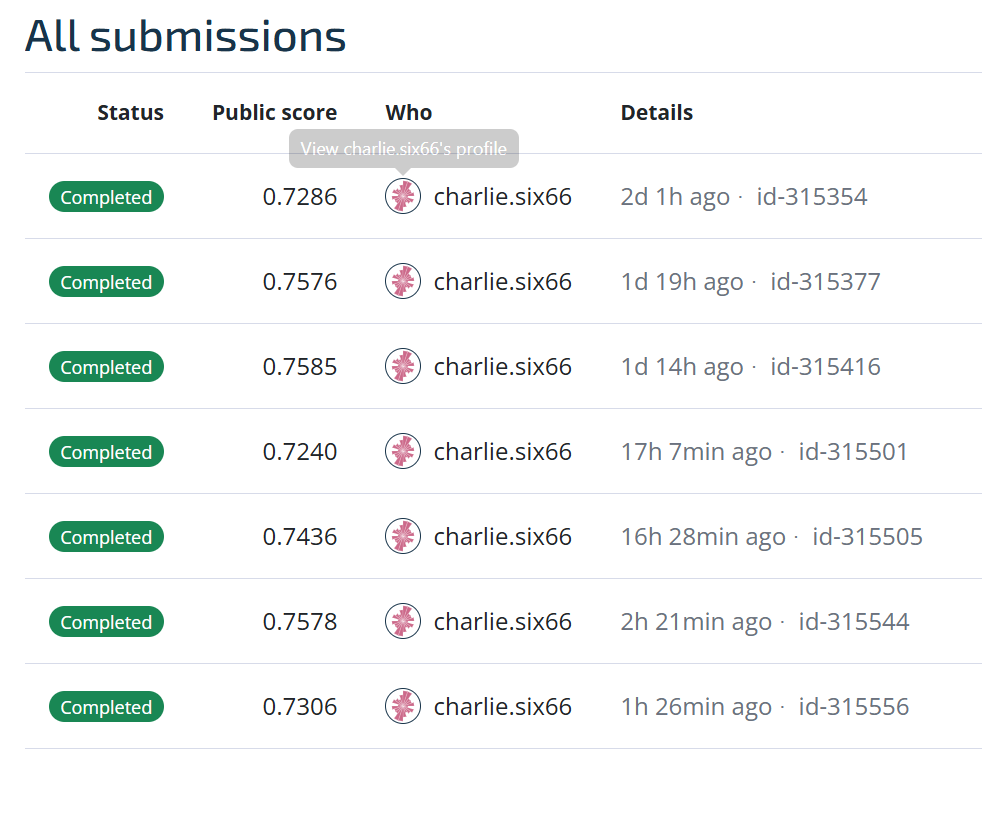